PHASE 5 — EWMA VOLATILITY SCALING

1. Imports
2. Load portfolio returns
3. Validate data
4. Set model parameters
5. Calculate EWMA variance
6. Calculate EWMA volatility
7. Plot EWMA volatility
8. Scale historical returns
9. Plot raw vs scaled returns
10. Calculate 250D EWMA VaR
11. Calculate 500D EWMA VaR
12. Calculate 750D EWMA VaR
13. Calculate rolling EWMA VaR
14. Load Phase 4 Historical VaR
15. Compare Historical vs EWMA VaR
16. Exception analysis
17. Save results
18. Final Phase 5 summary

In [1]:
print("hello world")

hello world


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

from src.risk.ewma import (
    calculate_ewma_variance,
    calculate_ewma_volatility,
)

from src.risk.volatility_scaling import (
    scale_returns,
)

from src.risk.ewma_var import (
    calculate_ewma_var,
    calculate_ewma_monetary_var,
    calculate_rolling_ewma_var,
)

In [4]:
portfolio_path = (
    PROJECT_ROOT
    / "data"
    / "portfolio"
    / "portfolio_daily.csv"
)

portfolio = pd.read_csv(
    portfolio_path
)

portfolio.head()

portfolio.columns

Index(['Date', 'Portfolio Return', 'Portfolio P&L', 'Portfolio Value'], dtype='str')

In [5]:
portfolio["Date"] = pd.to_datetime(
    portfolio["Date"]
)

portfolio = portfolio.sort_values(
    "Date"
)

returns = (
    portfolio
    .set_index("Date")["Portfolio Return"]
    .dropna()
)

returns.name = "Portfolio Return"

In [6]:
EWMA_LAMBDA = 0.94

CONFIDENCE_LEVEL = 0.95

WINDOWS = [
    250,
    500,
    750,
]

In [7]:
ewma_variance = calculate_ewma_variance(
    returns,
    lmbda=EWMA_LAMBDA,
)

ewma_volatility = calculate_ewma_volatility(
    returns,
    lmbda=EWMA_LAMBDA,
)

In [8]:
pd.DataFrame({
    "Return": returns,
    "EWMA Variance": ewma_variance,
    "EWMA Volatility": ewma_volatility,
}).tail()

,Return,EWMA Variance,EWMA Volatility
Date,,,
2026-07-27,-0.001628,0.000143,0.011938
2026-07-28,0.006559,0.000134,0.011581
2026-07-29,-0.014090,0.000129,0.011343
2026-07-30,0.025161,0.000133,0.011526
2026-07-31,0.015212,0.000163,0.012762


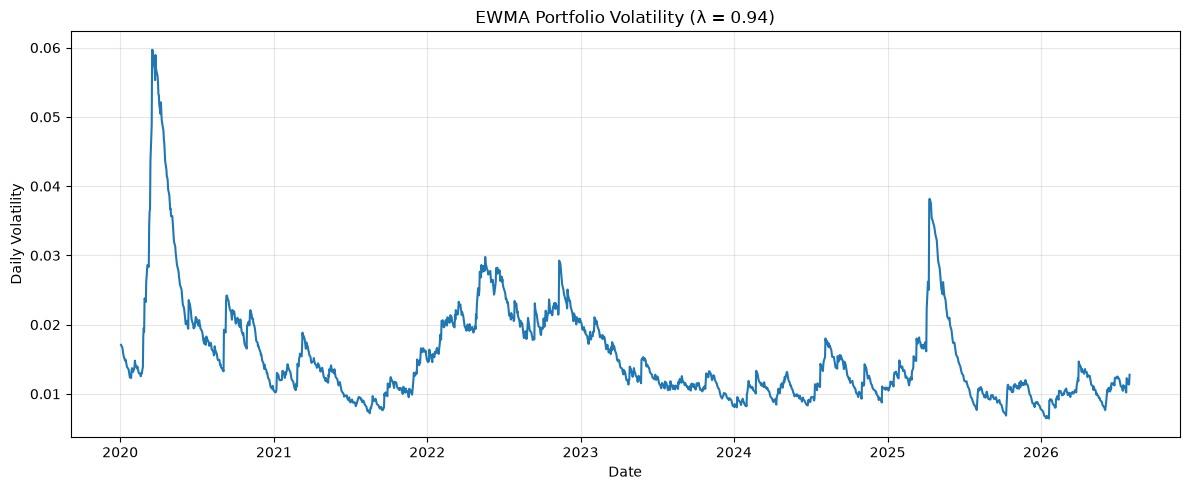

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    ewma_volatility.index,
    ewma_volatility,
)

plt.title(
    "EWMA Portfolio Volatility (λ = 0.94)"
)

plt.xlabel("Date")
plt.ylabel("Daily Volatility")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
current_volatility = (
    ewma_volatility.iloc[-1]
)

scaled_returns = scale_returns(
    returns,
    ewma_volatility,
    current_volatility,
)

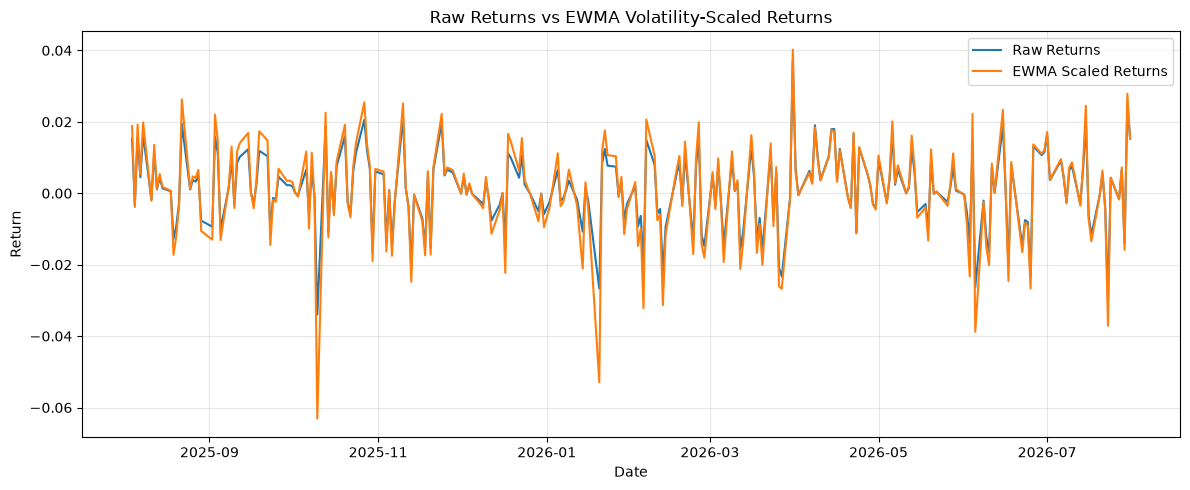

In [11]:
plot_data = pd.DataFrame({
    "Raw Return": returns,
    "Scaled Return": scaled_returns,
}).tail(250)

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data.index,
    plot_data["Raw Return"],
    label="Raw Returns",
)

plt.plot(
    plot_data.index,
    plot_data["Scaled Return"],
    label="EWMA Scaled Returns",
)

plt.title(
    "Raw Returns vs EWMA Volatility-Scaled Returns"
)

plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
ewma_var_results = {}

for window in WINDOWS:

    ewma_var_results[window] = (
        calculate_ewma_var(
            returns,
            confidence_level=CONFIDENCE_LEVEL,
            window=window,
            lmbda=EWMA_LAMBDA,
        )
    )

ewma_var_results

{250: 0.021811711263053393,
 500: 0.023118945274599588,
 750: 0.021962659674722686}

In [13]:
for window, var in ewma_var_results.items():

    print(
        f"{window}D EWMA VaR: "
        f"{var:.4%}"
    )

250D EWMA VaR: 2.1812%
500D EWMA VaR: 2.3119%
750D EWMA VaR: 2.1963%


In [14]:
portfolio_value = (
    portfolio["Portfolio Value"].iloc[-1]
)

In [15]:
for window in WINDOWS:

    monetary_var = (
        calculate_ewma_monetary_var(
            returns,
            portfolio_value,
            confidence_level=CONFIDENCE_LEVEL,
            window=window,
            lmbda=EWMA_LAMBDA,
        )
    )

    print(
        f"{window}D EWMA Monetary VaR: "
        f"₹{monetary_var:,.2f}"
    )

250D EWMA Monetary VaR: ₹85,703.06
500D EWMA Monetary VaR: ₹90,839.47
750D EWMA Monetary VaR: ₹86,296.17


In [16]:
rolling_ewma_var = (
    calculate_rolling_ewma_var(
        returns,
        confidence_level=CONFIDENCE_LEVEL,
        window=250,
        lmbda=EWMA_LAMBDA,
    )
)

In [17]:
historical_var_path = (
    PROJECT_ROOT
    / "data"
    / "risk"
    / "rolling_var.csv"
)

historical_var = pd.read_csv(
    historical_var_path,
    index_col=0,
    parse_dates=True,
)

historical_var.head()

,VaR_95_250D,VaR_99_250D,VaR_99_5_250D,VaR_95_500D,VaR_99_500D,VaR_99_5_500D,VaR_95_750D,VaR_99_750D,VaR_99_5_750D
Date,,,,,,,,,
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
historical_var.columns

Index(['VaR_95_250D', 'VaR_99_250D', 'VaR_99_5_250D', 'VaR_95_500D',
       'VaR_99_500D', 'VaR_99_5_500D', 'VaR_95_750D', 'VaR_99_750D',
       'VaR_99_5_750D'],
      dtype='str')

In [19]:
historical_var_series = (
    historical_var.iloc[:, 0]
)

In [20]:
comparison = pd.concat(
    [
        historical_var_series.rename(
            "Historical VaR"
        ),
        rolling_ewma_var.rename(
            "EWMA VaR"
        ),
    ],
    axis=1,
).dropna()

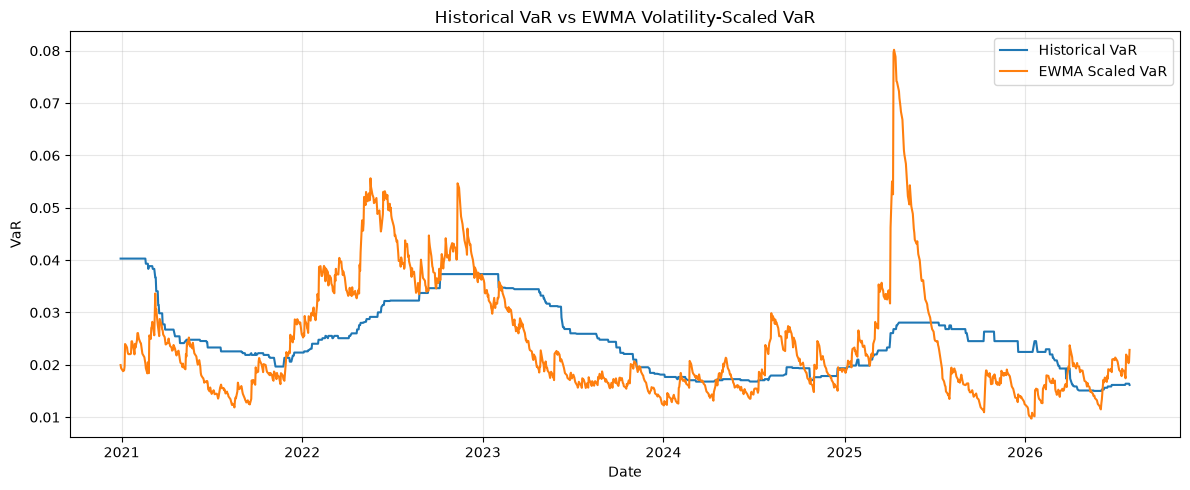

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["Historical VaR"],
    label="Historical VaR",
)

plt.plot(
    comparison.index,
    comparison["EWMA VaR"],
    label="EWMA Scaled VaR",
)

plt.title(
    "Historical VaR vs EWMA Volatility-Scaled VaR"
)

plt.xlabel("Date")
plt.ylabel("VaR")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
actual_losses = -returns

In [23]:
exceptions = pd.concat(
    [
        actual_losses.rename(
            "Actual Loss"
        ),
        historical_var_series.rename(
            "Historical VaR"
        ),
        rolling_ewma_var.rename(
            "EWMA VaR"
        ),
    ],
    axis=1,
).dropna()

In [24]:
exceptions[
    "Historical Exception"
] = (
    exceptions["Actual Loss"]
    > exceptions["Historical VaR"]
)

exceptions[
    "EWMA Exception"
] = (
    exceptions["Actual Loss"]
    > exceptions["EWMA VaR"]
)

In [25]:
historical_exception_count = (
    exceptions["Historical Exception"]
    .sum()
)

ewma_exception_count = (
    exceptions["EWMA Exception"]
    .sum()
)

print(
    "Historical VaR exceptions:",
    historical_exception_count,
)

print(
    "EWMA VaR exceptions:",
    ewma_exception_count,
)

Historical VaR exceptions: 71
EWMA VaR exceptions: 80


In [26]:
risk_path = (
    PROJECT_ROOT
    / "data"
    / "risk"
)

risk_path.mkdir(
    parents=True,
    exist_ok=True,
)

In [27]:
ewma_volatility.to_csv(
    risk_path
    / "ewma_volatility.csv"
)

In [28]:
scaled_returns.to_csv(
    risk_path
    / "ewma_scaled_returns.csv"
)

In [29]:
rolling_ewma_var.to_csv(
    risk_path
    / "ewma_var.csv"
)